# Employee Attrition Prediction using ANN

**Student:** Prajwol Sapkota
**Course:** ANN / Deep Learning

---

## 1. Objective

Attrition means an employee leaving the company. Replacing an employee costs time and
money, so HR wants to know **who is likely to leave** before they resign.

In this project I build an **ANN** that takes an employee's details (age, salary,
overtime, satisfaction, etc.) and predicts whether they will leave (`Yes`) or stay (`No`).
This is a **binary classification** problem.

Only **16% of employees left**, so the data is **imbalanced**. A model that always
predicts "stays" would get 84% accuracy but be useless — so I use class weights and check
precision and recall, not just accuracy.

In [1]:
# --- Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import json, os, random

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix, roc_curve,
                             roc_auc_score, precision_recall_curve, average_precision_score,
                             accuracy_score, precision_score, recall_score, f1_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Fixing the seed so that I get the same result every time I run the notebook
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)

TensorFlow : 2.21.0
Keras      : 3.15.1


In [2]:
# --- Colors and style used for all the graphs ---
STAY, LEFT = "#2a78d6", "#eb6834"     # blue = stayed, orange = left
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
SEQ = "#2a78d6"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 10, "axes.grid": True, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "font.size": 10, "figure.dpi": 110, "savefig.bbox": "tight",
})

def pct_axis(ax, axis="y"):
    # Show the axis values as percentages
    f = mticker.FuncFormatter(lambda v, _: f"{v:.0%}")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(f)

---
## 2. Dataset

I used the **IBM HR Analytics Employee Attrition** dataset. It has **1,470 employees**
and **35 columns**. The target column is `Attrition` (Yes / No).

In [3]:
df = pd.read_csv("../dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(f"Rows: {df.shape[0]}   Columns: {df.shape[1]}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
df.head()

Rows: 1470   Columns: 35
Missing values: 0
Duplicate rows: 0


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# Checking the columns and their types
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "unique": df.nunique(),
    "example": [df[c].iloc[0] for c in df.columns],
})
summary

,dtype,unique,example
Age,int64,43,41
Attrition,str,2,Yes
BusinessTravel,str,3,Travel_Rarely
DailyRate,int64,886,1102
Department,str,3,Sales
DistanceFromHome,int64,29,1
Education,int64,5,2
EducationField,str,6,Life Sciences
EmployeeCount,int64,1,1
EmployeeNumber,int64,1470,1


### 2.1 Useless columns

Some columns cannot help in prediction, so I remove them:

- `EmployeeCount`, `Over18`, `StandardHours` — these have the **same value for every
  employee**, so they give no information.
- `EmployeeNumber` — this is just an **ID number**. If I keep it the network may simply
  memorise the IDs, which is overfitting.

In [5]:
nun = df.nunique()
constant_cols = list(nun[nun == 1].index)        # only 1 unique value
id_cols       = list(nun[nun == len(df)].index)  # unique for every row

print("Constant columns  :", constant_cols)
print("Identifier columns:", id_cols)

DROP_COLS = constant_cols + id_cols

Constant columns  : ['EmployeeCount', 'Over18', 'StandardHours']
Identifier columns: ['EmployeeNumber']


---
## 3. Exploratory Data Analysis (EDA)

Before training, I plot the data to see which factors are related to attrition.

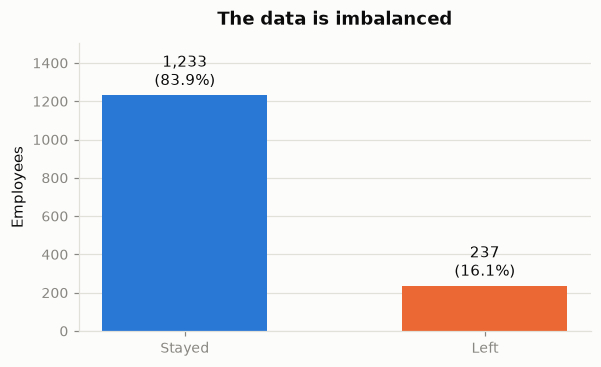

Attrition rate = 16.1%


In [6]:
# --- How many left vs stayed ---
counts = df["Attrition"].value_counts()
n_stay, n_left = counts["No"], counts["Yes"]
rate = n_left / len(df)

fig, ax = plt.subplots(figsize=(6, 3.4))
bars = ax.bar(["Stayed", "Left"], [n_stay, n_left], color=[STAY, LEFT], width=0.55)
for b, v in zip(bars, [n_stay, n_left]):
    ax.text(b.get_x() + b.get_width()/2, v + 25, f"{v:,}\n({v/len(df):.1%})",
            ha="center", va="bottom", fontsize=10, color=INK)
ax.set_title("The data is imbalanced")
ax.set_ylabel("Employees")
ax.set_ylim(0, n_stay * 1.22)
ax.grid(axis="x", visible=False)
plt.show()

print(f"Attrition rate = {rate:.1%}")

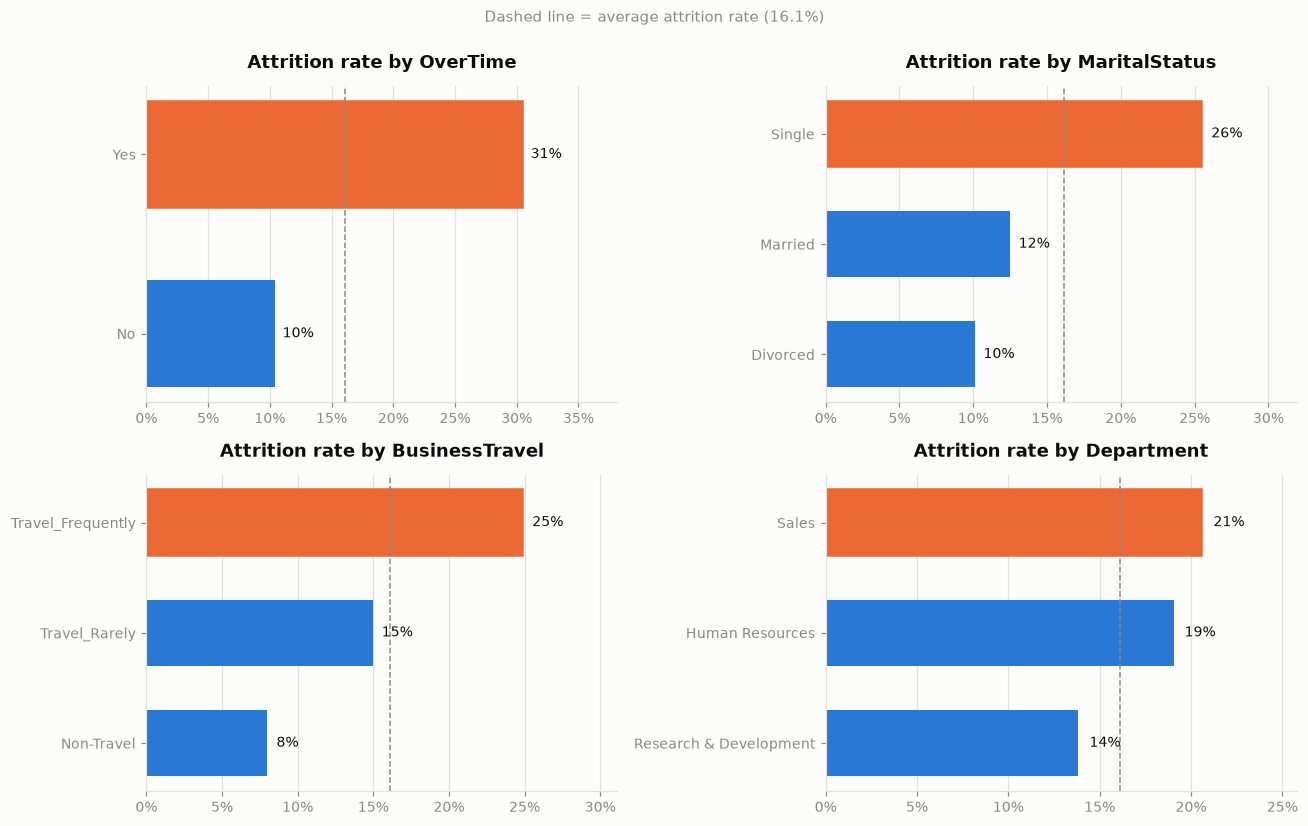

In [7]:
# --- Attrition rate for different categories ---
# I use the RATE and not the count, because a big department will obviously
# have more leavers just because it has more people.
cat_feats = ["OverTime", "MaritalStatus", "BusinessTravel", "Department"]

fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))
for ax, col in zip(axes.ravel(), cat_feats):
    g = (df.groupby(col, observed=True)["Attrition"]
           .apply(lambda s: (s == "Yes").mean())
           .sort_values(ascending=False))
    bars = ax.barh(g.index.astype(str), g.values, color=SEQ, height=0.6)
    bars[0].set_color(LEFT)
    for b, v in zip(bars, g.values):
        ax.text(v + 0.006, b.get_y() + b.get_height()/2, f"{v:.0%}",
                va="center", fontsize=9, color=INK)
    ax.axvline(rate, color=MUTED, lw=1, ls="--")
    ax.set_title(f"Attrition rate by {col}")
    ax.set_xlim(0, max(g.values) * 1.25)
    pct_axis(ax, "x")
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)

fig.suptitle("Dashed line = average attrition rate (16.1%)", y=0.995,
             fontsize=9.5, color=MUTED)
plt.tight_layout()
plt.show()

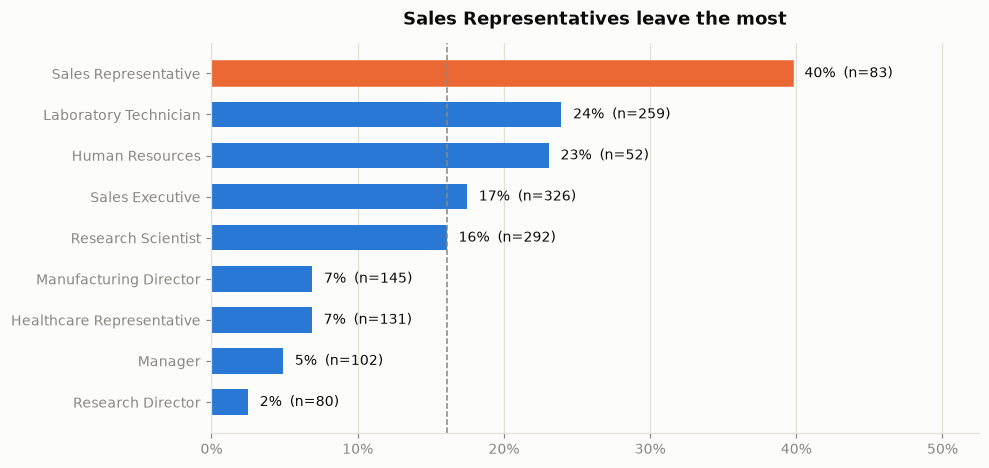

In [8]:
# --- Attrition rate by job role ---
g = (df.groupby("JobRole", observed=True)["Attrition"]
       .agg(rate=lambda s: (s == "Yes").mean(), n="size")
       .sort_values("rate", ascending=True))

fig, ax = plt.subplots(figsize=(9, 4.6))
bars = ax.barh(g.index, g["rate"], color=SEQ, height=0.62)
bars[-1].set_color(LEFT)
for b, (r_, n_) in zip(bars, g[["rate", "n"]].values):
    ax.text(r_ + 0.008, b.get_y() + b.get_height()/2, f"{r_:.0%}  (n={int(n_)})",
            va="center", fontsize=9, color=INK)
ax.axvline(rate, color=MUTED, lw=1, ls="--")
ax.set_title("Sales Representatives leave the most")
ax.set_xlim(0, g["rate"].max() * 1.32)
pct_axis(ax, "x")
ax.grid(axis="y", visible=False)
plt.show()

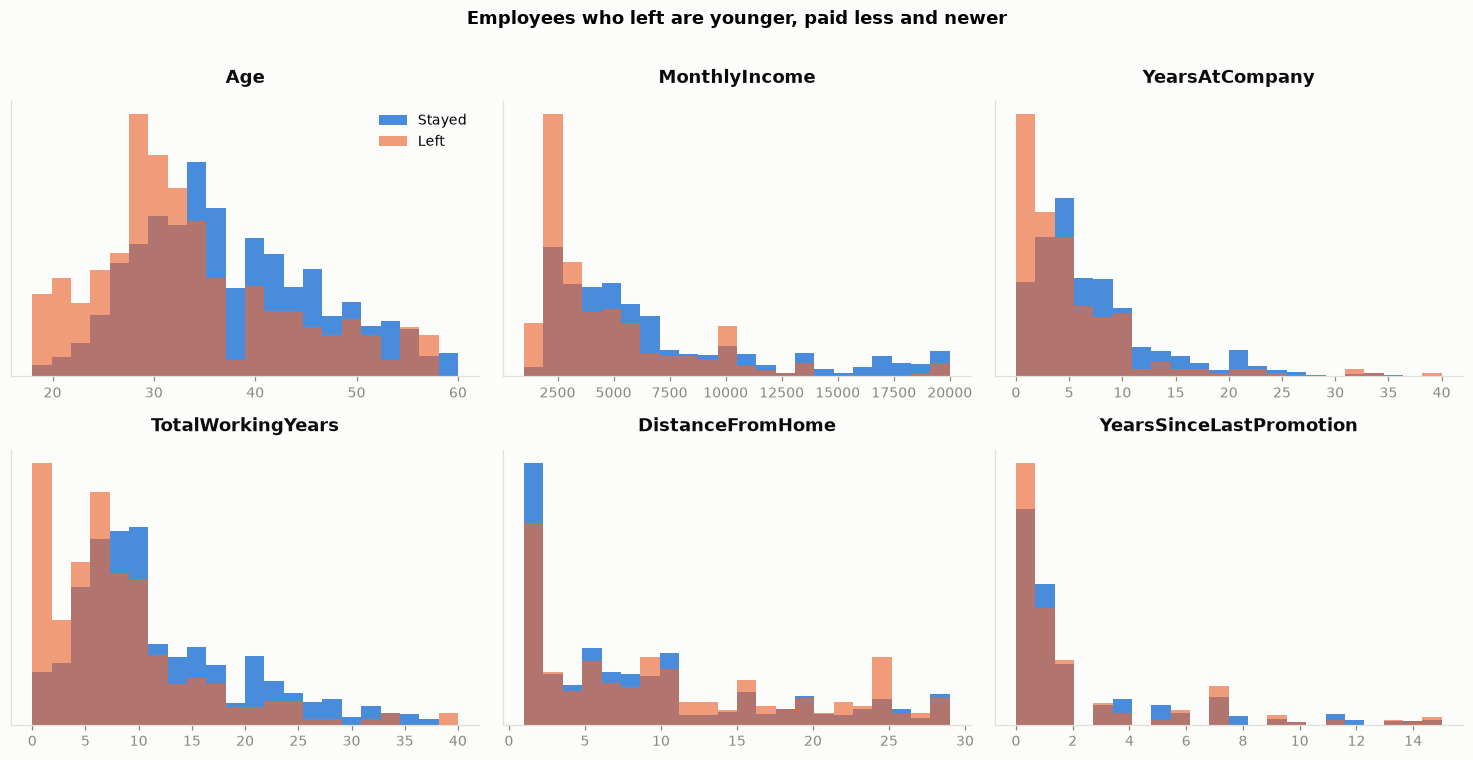

In [9]:
# --- Numeric columns: compare leavers and stayers ---
num_feats = ["Age", "MonthlyIncome", "YearsAtCompany", "TotalWorkingYears",
             "DistanceFromHome", "YearsSinceLastPromotion"]

fig, axes = plt.subplots(2, 3, figsize=(13.5, 6.8))
for ax, col in zip(axes.ravel(), num_feats):
    stay = df.loc[df.Attrition == "No",  col]
    left = df.loc[df.Attrition == "Yes", col]
    bins = np.histogram_bin_edges(df[col], bins=22)
    ax.hist(stay, bins=bins, color=STAY, alpha=0.85, label="Stayed", density=True)
    ax.hist(left, bins=bins, color=LEFT, alpha=0.65, label="Left",   density=True)
    ax.set_title(col)
    ax.set_yticks([])
    ax.grid(visible=False)
axes.ravel()[0].legend(loc="upper right")
fig.suptitle("Employees who left are younger, paid less and newer",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

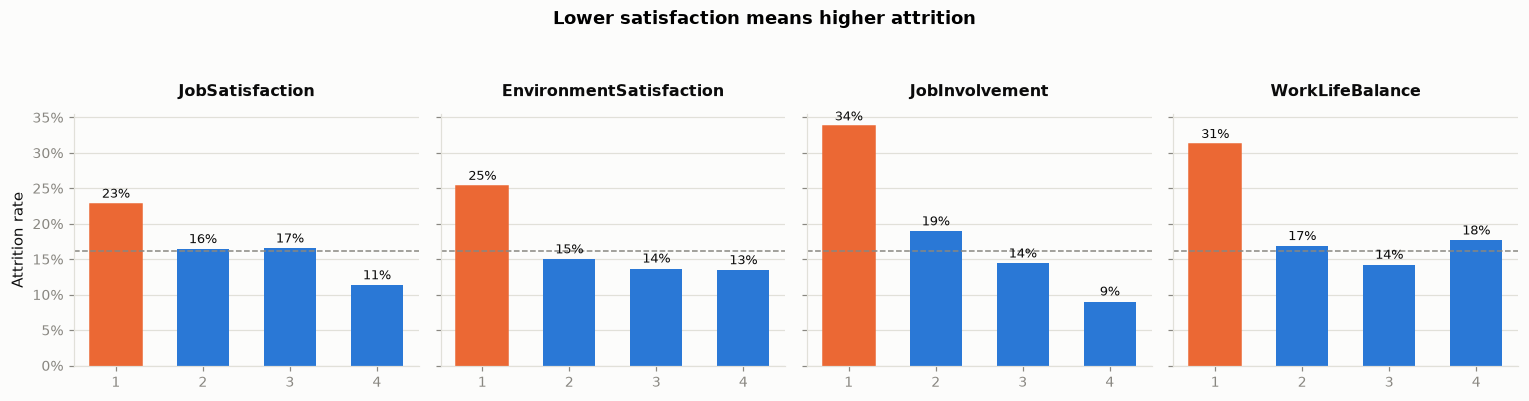

In [10]:
# --- Satisfaction ratings (1 = Low, 4 = Very High) ---
sat_feats = ["JobSatisfaction", "EnvironmentSatisfaction",
             "JobInvolvement", "WorkLifeBalance"]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for ax, col in zip(axes, sat_feats):
    g = df.groupby(col, observed=True)["Attrition"].apply(lambda s: (s == "Yes").mean())
    bars = ax.bar(g.index.astype(str), g.values, color=SEQ, width=0.6)
    bars[0].set_color(LEFT)
    for b, v in zip(bars, g.values):
        ax.text(b.get_x()+b.get_width()/2, v+0.004, f"{v:.0%}",
                ha="center", va="bottom", fontsize=8.5, color=INK)
    ax.set_title(col, fontsize=10.5)
    ax.axhline(rate, color=MUTED, lw=1, ls="--")
    ax.grid(axis="x", visible=False)
    pct_axis(ax)
axes[0].set_ylabel("Attrition rate")
fig.suptitle("Lower satisfaction means higher attrition",
             fontsize=12, fontweight="bold", y=1.06)
plt.tight_layout()
plt.show()

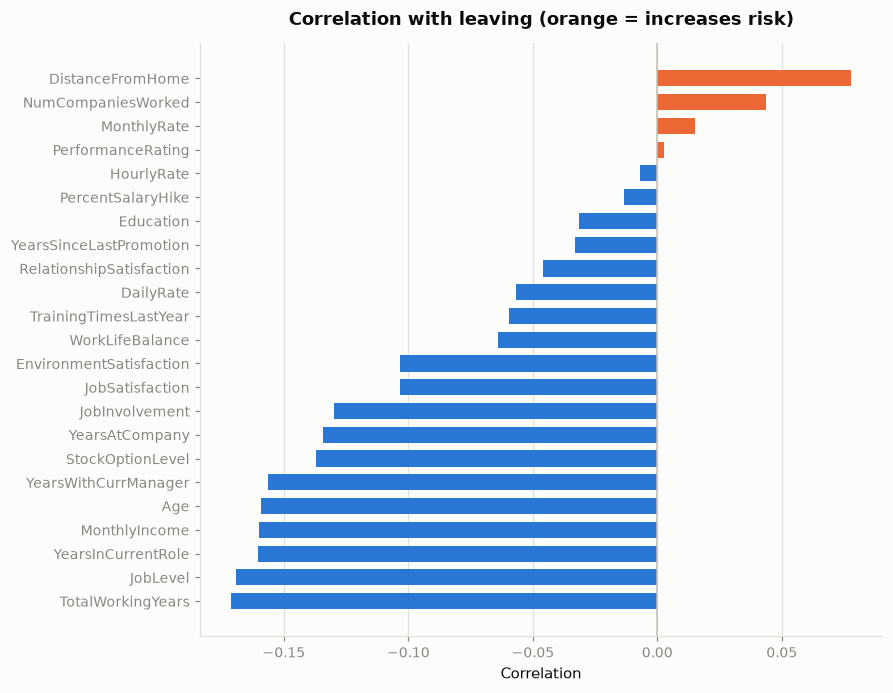

In [11]:
# --- Correlation of numeric columns with attrition ---
tmp = df.drop(columns=DROP_COLS).copy()
tmp["AttritionFlag"] = (tmp["Attrition"] == "Yes").astype(int)
corr = (tmp.select_dtypes(include=np.number).corr()["AttritionFlag"]
          .drop("AttritionFlag").sort_values())

fig, ax = plt.subplots(figsize=(8, 7))
colors = [LEFT if v > 0 else STAY for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, height=0.68)
ax.axvline(0, color="#c3c2b7", lw=1)
ax.set_title("Correlation with leaving (orange = increases risk)")
ax.set_xlabel("Correlation")
ax.grid(axis="y", visible=False)
plt.show()

### What I found from EDA

- **OverTime** is the biggest factor — about **31%** of employees doing overtime left,
  compared to only **10%** who did not.
- **Younger, low salary and newly joined** employees leave more.
- **Sales Representative** and **Laboratory Technician** have the highest attrition.
- **Single** employees and employees who **travel frequently** leave more.
- **Low satisfaction** (job, environment, work-life balance) increases attrition.

No single column can separate the two classes alone, so a neural network which combines
all of them should work better than looking at one column at a time.

---
## 4. Data Preprocessing

An ANN only accepts numbers, and all inputs should be on a similar scale.

1. **Convert target** `Yes`/`No` into `1`/`0`.
2. **One-hot encoding** for text columns like `JobRole` — using 1, 2, 3 instead would
   wrongly mean one job is "bigger" than another.
3. **Split** into train / validation / test.
4. **Standardize** — `MonthlyIncome` is in thousands but `JobSatisfaction` is only 1–4,
   so without scaling the big numbers dominate training.

In [12]:
data = df.drop(columns=DROP_COLS)

# 1. Target -> 0 / 1
y = (data["Attrition"] == "Yes").astype(int).values
X_raw = data.drop(columns=["Attrition"])

# 2. One-hot encoding for all non-numeric columns
cat_cols = X_raw.select_dtypes(exclude=[np.number]).columns.tolist()
X = pd.get_dummies(X_raw, columns=cat_cols, drop_first=True).astype("float32")

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Columns before one-hot: {X_raw.shape[1]}  ->  after one-hot: {X.shape[1]}")

Categorical columns (7): ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Columns before one-hot: 30  ->  after one-hot: 44


In [13]:
# 3. Splitting the data.
#    stratify -> keeps the same 16% leaver ratio in every split, which is important
#    because the number of leavers is small.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X.values, y, test_size=0.20, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.15, random_state=SEED, stratify=y_train_full)

# 4. Standardization.
#    The scaler is fitted only on training data. If I fit it on the full data then
#    information from the test set leaks into training, which gives a fake high score.
scaler  = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:11s}: {len(yy):4d} employees  ({yy.mean():.1%} left)")

Train      :  999 employees  (16.1% left)
Validation :  177 employees  (16.4% left)
Test       :  294 employees  (16.0% left)


### Class weights

Since only 16% of employees left, the network can get a high score by always predicting
"stays". To stop this, I give a **higher weight to the "Left" class** so that the model
is punished more when it misses a leaver.

In [14]:
weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: float(weights[0]), 1: float(weights[1])}
print("Class weights:", {k: round(v, 3) for k, v in class_weight.items()})
print("So one 'Left' example counts about "
      f"{class_weight[1]/class_weight[0]:.1f} times more than a 'Stayed' example.")

Class weights: {0: 0.596, 1: 3.102}
So one 'Left' example counts about 5.2 times more than a 'Stayed' example.


---
## 5. ANN Architecture

I used a **feed-forward neural network** (fully connected layers).

| Layer | Neurons | Activation |
|---|---|---|
| Input | 44 | — |
| Hidden 1 | 32 | ReLU |
| Dropout (0.3) | — | — |
| Hidden 2 | 16 | ReLU |
| Output | 1 | Sigmoid |

**Why these choices**

- **ReLU** in hidden layers — fast, and avoids the vanishing gradient problem.
- **Sigmoid** in output — gives a value between 0 and 1 = probability of leaving.
- **Binary cross-entropy** loss + **Adam** optimizer (lr = 0.0005) — standard for
  two-class problems.
- **Dropout (0.3)** and **L2** — to reduce overfitting.

**Why such a small network?** I tried bigger ones and they performed worse:

| Network | Test ROC-AUC |
|---|---|
| 128 → 64 | 0.753 |
| 64 → 32 → 16 | 0.769 |
| 64 → 32 | 0.773 |
| **32 → 16** | **0.775** |

There are only 999 training rows, so a big network overfits.

In [15]:
def build_model(n_features, seed=SEED):
    keras.utils.set_random_seed(seed)
    model = keras.Sequential([
        keras.Input(shape=(n_features,), name="input"),

        layers.Dense(32, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-2), name="hidden_1"),
        layers.Dropout(0.3, name="dropout_1"),

        layers.Dense(16, activation="relu",
                     kernel_regularizer=keras.regularizers.l2(1e-2), name="hidden_2"),

        layers.Dense(1, activation="sigmoid", name="output"),
    ], name="attrition_ann")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-4),
        loss="binary_crossentropy",
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")],
    )
    return model

model = build_model(X_train.shape[1])
model.summary()

Model: "attrition_ann"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │         1,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

---
## 6. Training

Two callbacks are used:

- **EarlyStopping** — stops when validation loss stops improving for 40 epochs and
  restores the best weights, so I don't have to guess the number of epochs.
- **ReduceLROnPlateau** — halves the learning rate when the model stops improving.

The **test set is not used during training at all** — only once in Section 7.

In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", mode="min", patience=40,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=12,
                                      min_lr=1e-5, verbose=0),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=500,
    batch_size=32,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=0,
)

print(f"Training stopped after {len(history.history['loss'])} epochs.")

Epoch 140: early stopping


Restoring model weights from the end of the best epoch: 100.


Training stopped after 140 epochs.


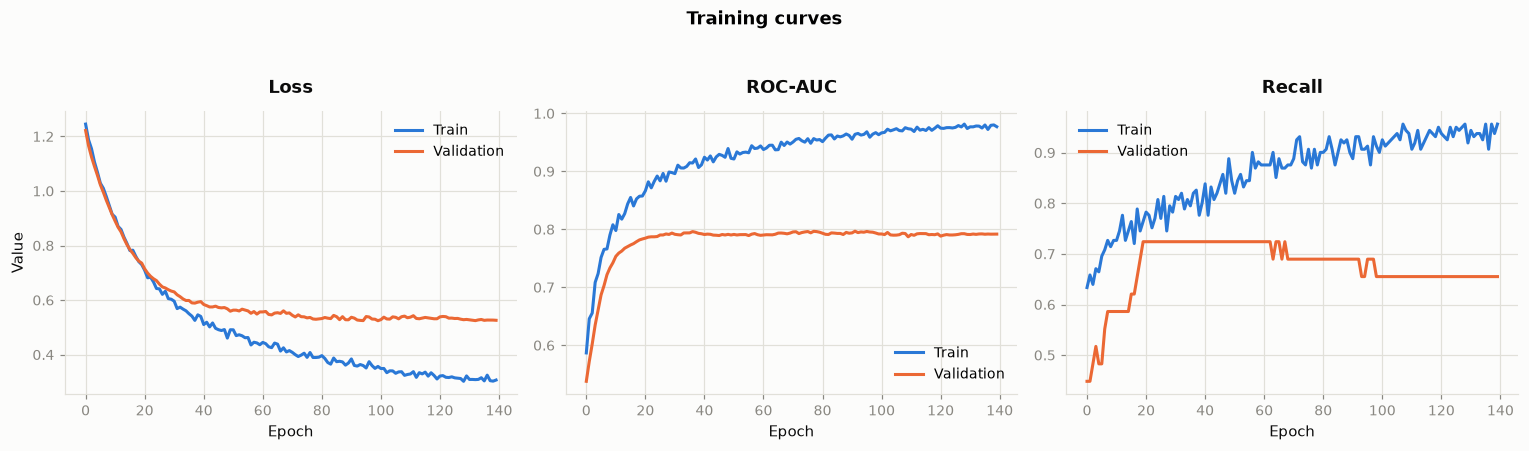

In [17]:
# --- Training graphs ---
h = history.history
pairs = [("loss", "val_loss", "Loss"),
         ("auc", "val_auc", "ROC-AUC"),
         ("recall", "val_recall", "Recall")]

fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
for ax, (tr, va, title) in zip(axes, pairs):
    ax.plot(h[tr], color=STAY, lw=2, label="Train")
    ax.plot(h[va], color=LEFT, lw=2, label="Validation")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend(loc="best")
axes[0].set_ylabel("Value")
fig.suptitle("Training curves", fontsize=12, fontweight="bold", y=1.04)
plt.tight_layout()
plt.show()

---
## 7. Evaluation

Now I test the model on the 294 employees it has never seen. Metrics used:

- **Recall** — out of employees who actually left, how many did the model catch?
- **Precision** — out of employees the model flagged, how many actually left?
- **ROC-AUC** — how well the model separates the two classes (0.5 = random guess).

In [18]:
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print("=" * 55)
print("TEST RESULTS  (threshold = 0.50)")
print("=" * 55)
print(f"Accuracy           : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (leavers): {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    (leavers): {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-score  (leavers): {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Stayed", "Left"], digits=3))

TEST RESULTS  (threshold = 0.50)
Accuracy           : 0.8197
Precision (leavers): 0.4483
Recall    (leavers): 0.5532
F1-score  (leavers): 0.4952
ROC-AUC            : 0.7587

              precision    recall  f1-score   support

      Stayed      0.911     0.870     0.890       247
        Left      0.448     0.553     0.495        47

    accuracy                          0.820       294
   macro avg      0.680     0.712     0.693       294
weighted avg      0.837     0.820     0.827       294



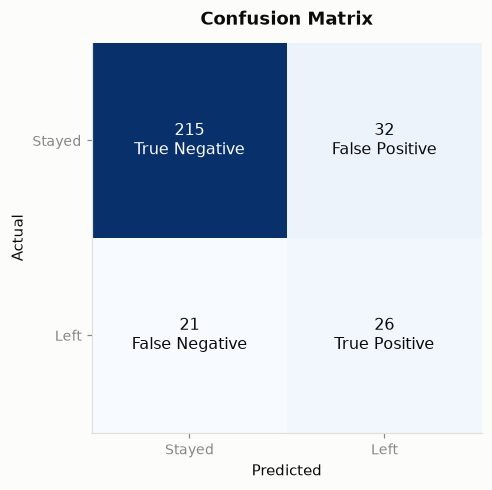

Leavers correctly caught : 26 out of 47
Leavers missed           : 21
False alarms             : 32


In [19]:
# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
ax.imshow(cm, cmap="Blues")
labels = ["Stayed", "Left"]
ax.set_xticks([0, 1], labels); ax.set_yticks([0, 1], labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
notes = [["True Negative", "False Positive"], ["False Negative", "True Positive"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]}\n{notes[i][j]}", ha="center", va="center",
                fontsize=10.5, color="white" if cm[i, j] > cm.max()/2 else INK)
ax.grid(visible=False)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Leavers correctly caught : {tp} out of {tp+fn}")
print(f"Leavers missed           : {fn}")
print(f"False alarms             : {fp}")

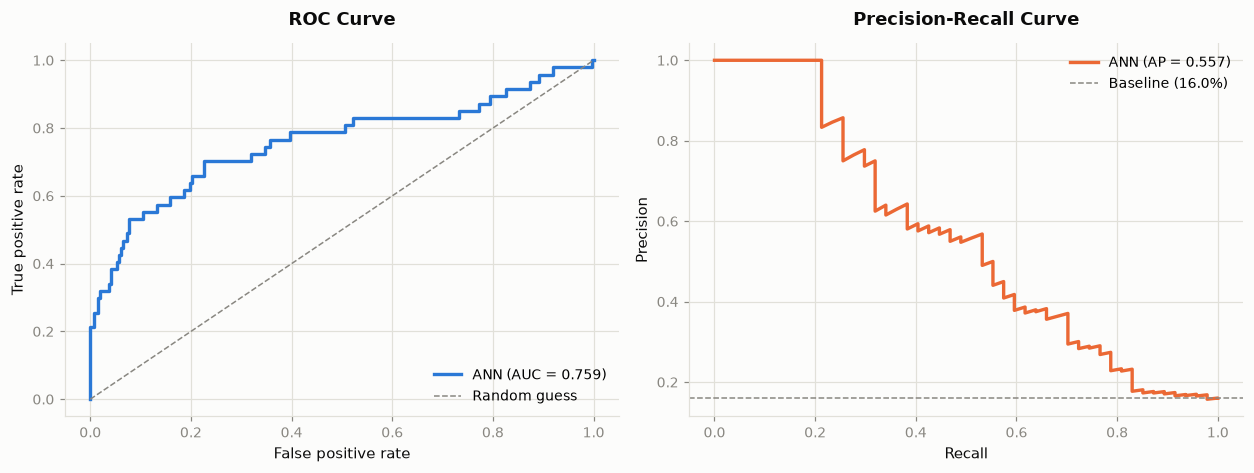

In [20]:
# --- ROC and Precision-Recall curves ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
prec, rec, _ = precision_recall_curve(y_test, y_prob)
auc, ap = roc_auc_score(y_test, y_prob), average_precision_score(y_test, y_prob)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.4))

a1.plot(fpr, tpr, color=STAY, lw=2.2, label=f"ANN (AUC = {auc:.3f})")
a1.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="Random guess")
a1.set_xlabel("False positive rate"); a1.set_ylabel("True positive rate")
a1.set_title("ROC Curve"); a1.legend(loc="lower right")

a2.plot(rec, prec, color=LEFT, lw=2.2, label=f"ANN (AP = {ap:.3f})")
a2.axhline(y_test.mean(), color=MUTED, lw=1, ls="--",
           label=f"Baseline ({y_test.mean():.1%})")
a2.set_xlabel("Recall"); a2.set_ylabel("Precision")
a2.set_title("Precision-Recall Curve"); a2.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 7.1 Choosing the threshold

The output layer gives a probability, so we need a cut-off to convert it into Yes/No.
0.5 is the default but not always the best. I try different thresholds and pick the one
with the best F1-score.

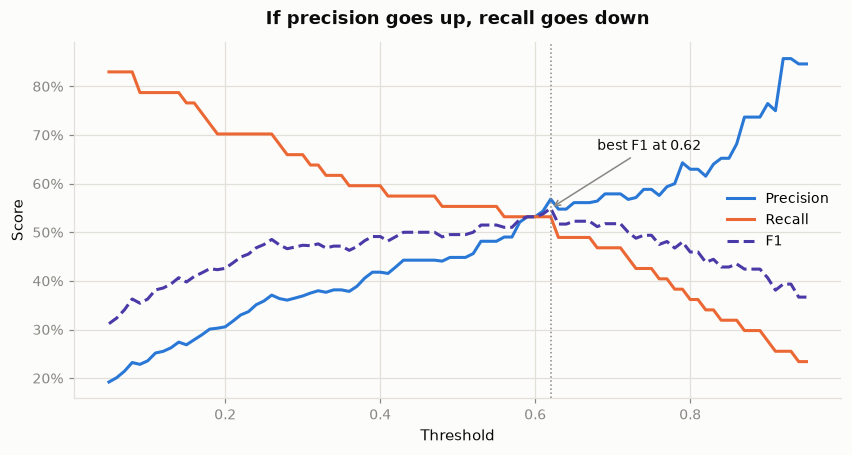

Best threshold = 0.62  ->  precision 0.568 | recall 0.532 | F1 0.549


In [21]:
rows = []
for t in np.arange(0.05, 0.96, 0.01):
    p = (y_prob >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, p, zero_division=0),
                 "recall":    recall_score(y_test, p, zero_division=0),
                 "f1":        f1_score(y_test, p, zero_division=0)})
sweep = pd.DataFrame(rows)
best = sweep.loc[sweep.f1.idxmax()]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.plot(sweep.threshold, sweep.precision, color=STAY, lw=2, label="Precision")
ax.plot(sweep.threshold, sweep.recall,    color=LEFT, lw=2, label="Recall")
ax.plot(sweep.threshold, sweep.f1,        color="#4a3aa7", lw=2, ls="--", label="F1")
ax.axvline(best.threshold, color=MUTED, lw=1, ls=":")
ax.annotate(f"best F1 at {best.threshold:.2f}",
            xy=(best.threshold, best.f1), xytext=(best.threshold + 0.06, best.f1 + 0.12),
            fontsize=9, color=INK,
            arrowprops=dict(arrowstyle="->", color=MUTED, lw=1))
ax.set_xlabel("Threshold"); ax.set_ylabel("Score")
ax.set_title("If precision goes up, recall goes down")
ax.legend(loc="center right")
pct_axis(ax)
plt.show()

print(f"Best threshold = {best.threshold:.2f}  ->  "
      f"precision {best.precision:.3f} | recall {best.recall:.3f} | F1 {best.f1:.3f}")

In [22]:
# --- Comparing default threshold and tuned threshold ---
BEST_T = float(best.threshold)

comparison = []
for name, t in [("Default (0.50)", 0.50), ("Tuned (best F1)", BEST_T)]:
    p = (y_prob >= t).astype(int)
    tn_, fp_, fn_, tp_ = confusion_matrix(y_test, p).ravel()
    comparison.append({
        "Threshold used": name,
        "Accuracy":  round(accuracy_score(y_test, p), 3),
        "Precision": round(precision_score(y_test, p, zero_division=0), 3),
        "Recall":    round(recall_score(y_test, p, zero_division=0), 3),
        "F1":        round(f1_score(y_test, p, zero_division=0), 3),
        "Leavers caught": f"{tp_}/{tp_+fn_}", "False alarms": fp_,
    })
pd.DataFrame(comparison).set_index("Threshold used")

,Accuracy,Precision,Recall,F1,Leavers caught,False alarms
Threshold used,,,,,,
Default (0.50),0.820,0.448,0.553,0.495,26/47,32
Tuned (best F1),0.861,0.568,0.532,0.549,25/47,19


---
## 8. Saving the Model

I save three files, because the saved model alone is not enough — new data must be
encoded and scaled in exactly the same way as the training data.

| File | Use |
|---|---|
| `attrition_ann.keras` | The trained network |
| `scaler.joblib` | The StandardScaler used |
| `metadata.json` | Column order, threshold and results |

In [23]:
import joblib

os.makedirs("../model", exist_ok=True)
model.save("../model/attrition_ann.keras")
joblib.dump(scaler, "../model/scaler.joblib")

y_best = (y_prob >= BEST_T).astype(int)
metadata = {
    "feature_names": X.columns.tolist(),
    "n_features": int(X.shape[1]),
    "decision_threshold": round(BEST_T, 2),
    "categorical_columns": cat_cols,
    "dropped_columns": DROP_COLS,
    "architecture": f"{X.shape[1]} -> 32(ReLU) -> Dropout(0.3) -> 16(ReLU) -> 1(Sigmoid)",
    "epochs_trained": len(history.history["loss"]),
    "test_metrics": {
        "accuracy":  round(float(accuracy_score(y_test, y_best)), 4),
        "precision": round(float(precision_score(y_test, y_best, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_test, y_best, zero_division=0)), 4),
        "f1":        round(float(f1_score(y_test, y_best, zero_division=0)), 4),
        "roc_auc":   round(float(roc_auc_score(y_test, y_prob)), 4),
    },
}
with open("../model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Files saved in ../model/:")
for f_ in sorted(os.listdir("../model")):
    if not f_.startswith("."):
        print(f"  {f_:24s} {os.path.getsize(f'../model/{f_}')/1024:8.1f} KB")

Files saved in ../model/:
  attrition_ann.keras          51.2 KB
  metadata.json                 1.8 KB
  scaler.joblib                 1.6 KB


### 8.1 Testing the model on new employees

A simple function that takes employee details and returns the risk of leaving.

In [24]:
def predict_attrition(employee: dict, threshold: float = BEST_T):
    # Takes a dictionary of employee details and returns the attrition risk
    row = pd.DataFrame([employee])
    row = pd.get_dummies(row, columns=[c for c in cat_cols if c in row.columns])
    # Make the columns exactly same as training data, missing ones become 0
    row = row.reindex(columns=X.columns, fill_value=0).astype("float32")

    prob = float(model.predict(scaler.transform(row.values), verbose=0).ravel()[0])
    band = "HIGH" if prob >= threshold else ("MEDIUM" if prob >= threshold*0.6 else "LOW")
    return {"probability": round(prob, 4),
            "prediction": "Will leave" if prob >= threshold else "Will stay",
            "risk": band}


# Two example employees
base = X_raw.median(numeric_only=True).to_dict()
mode = {c: X_raw[c].mode()[0] for c in cat_cols}

high_risk = {**base, **mode, "Age": 22, "MonthlyIncome": 2200, "OverTime": "Yes",
             "JobLevel": 1, "YearsAtCompany": 1, "TotalWorkingYears": 1,
             "JobSatisfaction": 1, "MaritalStatus": "Single",
             "JobRole": "Sales Representative", "BusinessTravel": "Travel_Frequently",
             "WorkLifeBalance": 1, "StockOptionLevel": 0}

low_risk  = {**base, **mode, "Age": 45, "MonthlyIncome": 15000, "OverTime": "No",
             "JobLevel": 4, "YearsAtCompany": 12, "TotalWorkingYears": 20,
             "JobSatisfaction": 4, "MaritalStatus": "Married",
             "JobRole": "Manager", "BusinessTravel": "Travel_Rarely",
             "WorkLifeBalance": 3, "StockOptionLevel": 2}

for name, emp in [("Young sales rep, overtime", high_risk),
                  ("Senior manager, no overtime", low_risk)]:
    r = predict_attrition(emp)
    print(f"{name:30s} -> {r['probability']:6.1%}  {r['prediction']:11s} [{r['risk']} risk]")

Young sales rep, overtime      ->  99.9%  Will leave  [HIGH risk]
Senior manager, no overtime    ->   0.8%  Will stay   [LOW risk]


---
## 9. Results

In [25]:
final = pd.DataFrame([
    {"Metric": "ROC-AUC",             "Value": round(roc_auc_score(y_test, y_prob), 3)},
    {"Metric": "Accuracy",            "Value": round(accuracy_score(y_test, y_best), 3)},
    {"Metric": "Precision (leavers)", "Value": round(precision_score(y_test, y_best, zero_division=0), 3)},
    {"Metric": "Recall (leavers)",    "Value": round(recall_score(y_test, y_best, zero_division=0), 3)},
    {"Metric": "F1 (leavers)",        "Value": round(f1_score(y_test, y_best, zero_division=0), 3)},
]).set_index("Metric")

print(f"Architecture : 44 -> 32 -> 16 -> 1")
print(f"Threshold    : {BEST_T:.2f}")
print(f"Epochs        : {len(history.history['loss'])}\n")
final

Architecture : 44 -> 32 -> 16 -> 1
Threshold    : 0.62
Epochs        : 140



,Value
Metric,
ROC-AUC,0.759
Accuracy,0.861
Precision (leavers),0.568
Recall (leavers),0.532
F1 (leavers),0.549


### Explanation of the results

- **ROC-AUC ≈ 0.76** — if we take one employee who left and one who stayed, the model
  gives the higher risk score to the correct one about 76% of the time. Random would be
  0.5, so the model has learned something useful.
- **Accuracy is not the main metric.** A "nobody leaves" model gets 83.9% accuracy but
  catches zero leavers.
- **Class weights were important** — without them the model predicted "stays" for almost
  everyone.

The score is not very high, which is expected — resignation also depends on personal
reasons (family, health, a better offer) that are not in the dataset.

## 10. Conclusion

I built an ANN (**44 → 32 → 16 → 1**, ReLU + dropout + L2) to predict employee attrition
and got **ROC-AUC ≈ 0.76** on the test set.

**What I learned**

1. For imbalanced data, **accuracy is misleading** — precision, recall and ROC-AUC give
   the real picture.
2. **Class weights** are necessary, otherwise the network ignores the minority class.
3. **A bigger network is not always better** — every increase in size lowered the score.
4. **The threshold can be tuned** to balance precision and recall.
5. The predictions **match the EDA** — overtime, low salary and low satisfaction increase
   the predicted risk.

**Limitations**

- Only 1,470 rows and 237 leavers — small for a neural network.
- The data is created by IBM, not real company data.
- Results come from one train/test split (around ±0.02 variation).

**Future work**

- **k-fold cross-validation** for more reliable results.
- **SMOTE** instead of class weights.
- **Keras Tuner** for automatic hyperparameter search.